# Tanager Mangrove Mapping - 02 Classification

| | |
|---|---|
| **Authors**     | Muhammad Wahyu Ramadhan, Athar Abdurrahman B., Diniyarti |
| **Competition** | Planet Tanager Open Data Competition 2026 |
| **Topic**       | Transferable Mangrove Extent Mapping Using Adaptive Spectral Thresholds |
| **Date**        | June 2026 |

---

**Scope:** Pseudo-label generation from adaptive thresholds, XGBoost training on Sangatta, accuracy evaluation, wall-to-wall extent map.

## 0. Environment Setup

In [6]:
"""%%javascript
function KeepAlive() {
  document.querySelector("#top-toolbar").click();
  console.log("keep alive: " + new Date().toLocaleTimeString());
}
setInterval(KeepAlive, 60000);  // klik setiap 60 detik"""

'%%javascript\nfunction KeepAlive() {\n  document.querySelector("#top-toolbar").click();\n  console.log("keep alive: " + new Date().toLocaleTimeString());\n}\nsetInterval(KeepAlive, 60000);  // klik setiap 60 detik'

In [7]:
# Install dependencies (Colab)
!pip install scikit-learn xgboost geopandas rasterio matplotlib joblib

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import sys
import json
from pathlib import Path

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio

# ============================================================
# Project root (adjust per environment)
# ============================================================
# Google Colab (Google Drive mounted)
ROOT = Path('/content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping')

# Local (uncomment if running locally)
# ROOT = Path('..').resolve()

DATA_PROC   = ROOT / 'data' / 'processed'
DATA_GMW    = ROOT / 'data' / 'gmw_v3'
OUT_MODELS  = ROOT / 'outputs' / 'models'
OUT_RESULTS = ROOT / 'outputs' / 'results'
OUT_FIGURES = ROOT / 'outputs' / 'figures'

# Ensure output folders exist
for d in (OUT_MODELS, OUT_RESULTS, OUT_FIGURES):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT))
from src.preprocessing import load_geotiff_bands, compute_all_indices
from src.spatial_viz import reproject_array_to_4326, format_map_axes
from src.classification import (
    generate_pseudo_labels,
    build_feature_matrix,
    split_data,
        train_xgboost,
        evaluate_model,
    compare_models,
    predict_extent,
    save_model
)

# ============================================================
# Scene IDs (same dict as 01_preprocessing.ipynb)
# ============================================================
SCENES = {
    'sangatta'   : '20250302_030003_92_4001',
    'gujarat'    : '20250311_061550_53_4001',
    'elsalvador' : '20250223_165546_32_4001',
    'belize'     : '20250824_171853_67_4001',
    'belize2'    : '20250824_171857_84_4001',
    'australia'  : '20250608_014315_58_4001',
}

SITE     = 'sangatta'
SCENE_ID = SCENES[SITE]

print(f'ROOT     : {ROOT}')
print(f'SITE     : {SITE}')
print(f'SCENE_ID : {SCENE_ID}')

ROOT     : /content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping
SITE     : sangatta
SCENE_ID : 20250302_030003_92_4001


In [10]:
# ============================================================
# Reload src modules during development
# ============================================================
import importlib
import src.preprocessing  as _pre
import src.classification as _cls
import src.evaluation     as _eval
import src.spatial_viz    as _sviz
importlib.reload(_pre)
importlib.reload(_cls)
importlib.reload(_eval)
importlib.reload(_sviz)
from src.preprocessing import load_geotiff_bands, compute_all_indices
from src.spatial_viz import reproject_array_to_4326, format_map_axes
from src.classification import (
    generate_pseudo_labels, build_feature_matrix, split_data,
    train_xgboost, evaluate_model,
    compare_models, predict_extent, save_model, load_model,
    tune_xgboost,
)
from src.evaluation import (
    rasterize_gmw, evaluate_against_gmw,
    plot_confusion_matrix, plot_agreement_map, build_agree_array,
)
print('Reloaded.')


Reloaded.


## 1. Load Indices + Thresholds

In [11]:
# ============================================================
# Load multiband GeoTIFF (produced in 01) and recompute indices
# ============================================================
data    = load_geotiff_bands(str(DATA_PROC), SCENE_ID, site=SITE)
indices = compute_all_indices(data)

print('Index statistics:')
for name, arr in indices.items():
    print(f'  {name:<8}: min={np.nanmin(arr):.3f}  max={np.nanmax(arr):.3f}  mean={np.nanmean(arr):.3f}')


  Bands loaded  : ['green', 'red', 'rededge', 'nir', 'swir1', 'swir2']
  CRS           : PROJCS["WGS 84 / UTM zone 50N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Index statistics:
  NDVI    : min=-1.000  max=1.000  mean=0.274
  MNDWI   : min=-1.000  max=1.000  mean=0.069
  NDMI    : min=-1.000  max=1.000  mean=0.302
  CMRI    : min=-2.000  max=2.000  mean=0.206
  NDRE    : min=-1.000  max=1.000  mean=0.139
  SAVI    : min=-0.285  max=0.821  mean=0.282
  MVI     : min=-1.000  max=20.000  mean=1.559
  EMI     : min=-1.000  max=1.000  mean=0.585


In [12]:
# ============================================================
# Load thresholds saved in 01_preprocessing.ipynb
# ============================================================
thresh_path = OUT_RESULTS / f'thresholds_{SITE}_{SCENE_ID}.json'
with open(thresh_path) as f:
    thresholds = json.load(f)

print('Thresholds loaded:')
for k, v in thresholds.items():
    print(f'  {k:<8}: {v:.4f}')


Thresholds loaded:
  NDVI    : 0.8744
  MNDWI   : -0.4707
  NDMI    : 0.2464
  CMRI    : 1.3364
  NDRE    : 0.4502
  SAVI    : 0.6209
  MVI     : 4.0449
  EMI     : 0.7158


In [13]:
# ============================================================
# Load coastal candidate mask (from 01_preprocessing)
# ============================================================
cand_path = DATA_PROC / f'candidate_{SITE}_{SCENE_ID}.tif'
with rasterio.open(cand_path) as src:
    candidate_mask = src.read(1).astype(bool)
print(f'Candidate mask loaded : {candidate_mask.sum():,} px ({100*candidate_mask.mean():.1f}%)')

# ============================================================
# Load hyperspectral diagnostic feature REIP (from 01_preprocessing)
# Saved on HDF5 grid (850x810 for Sangatta) -- must resample to
# GeoTIFF/indices grid (667x915) before use in classifier.
# Shape mismatch arises because hdf5_to_geotiff() reprojects to a
# slightly different pixel grid than the original HDF5.
# ============================================================
from rasterio.warp import reproject, Resampling

def resample_to_grid(src_array, src_transform, src_crs,
                     dst_shape, dst_transform, dst_crs):
    """Resample 2D float32 array from source grid to destination grid."""
    dst = np.full(dst_shape, np.nan, dtype=np.float32)
    reproject(
        source=src_array,
        destination=dst,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.bilinear,
        src_nodata=np.nan,
        dst_nodata=np.nan,
    )
    return dst

# Target grid: same as spectral indices
dst_shape     = indices['NDMI'].shape
dst_transform = data['transform']
dst_crs       = data['crs']

reip_path = DATA_PROC / f'reip_{SITE}_{SCENE_ID}.tif'

with rasterio.open(reip_path) as src:
    reip_map_r = resample_to_grid(
        src.read(1), src.transform, src.crs,
        dst_shape, dst_transform, dst_crs
    )

extra_features = {
    'REIP' : reip_map_r,
}
print(f'REIP resampled : {np.isfinite(reip_map_r).sum():,} valid px, mean={np.nanmean(reip_map_r):.1f} nm')


Candidate mask loaded : 57,014 px (8.3%)


REIP resampled : 497,797 valid px, mean=725.8 nm


## 2. Pseudo-label Generation

In [14]:
# ============================================================
# AND logic: MVI > threshold AND NDMI > threshold
# Spatially constrained to coastal candidate zone
# ============================================================
labels = generate_pseudo_labels(indices, thresholds,
                                 candidate_mask=candidate_mask)


  Pseudo-labels generated:
  mangrove     : 8,249 px
  non-mangrove : 489,548 px
  invalid      : 190,703 px
  (constrained to coastal candidate zone)


## 3. Feature Matrix + Train/Test Split

In [15]:
X, y, feature_names = build_feature_matrix(
    indices, labels, extra_features=extra_features
)
X_train, X_test, y_train, y_test = split_data(X, y)


  Feature matrix : 497,797 samples x 9 features
  Features       : ['NDVI', 'MNDWI', 'NDMI', 'CMRI', 'NDRE', 'SAVI', 'MVI', 'EMI', 'REIP']
  Train samples  : 398,237
  Test samples   : 99,560


In [16]:
print(f'Total features used for training: {len(feature_names)}')
print('Feature list:')
for i, name in enumerate(feature_names, 1):
    print(f'  {i}. {name}')

# Also check the shape of the training matrix
print(f'\nShape of X_train: {X_train.shape}')

Total features used for training: 9
Feature list:
  1. NDVI
  2. MNDWI
  3. NDMI
  4. CMRI
  5. NDRE
  6. SAVI
  7. MVI
  8. EMI
  9. REIP

Shape of X_train: (398237, 9)


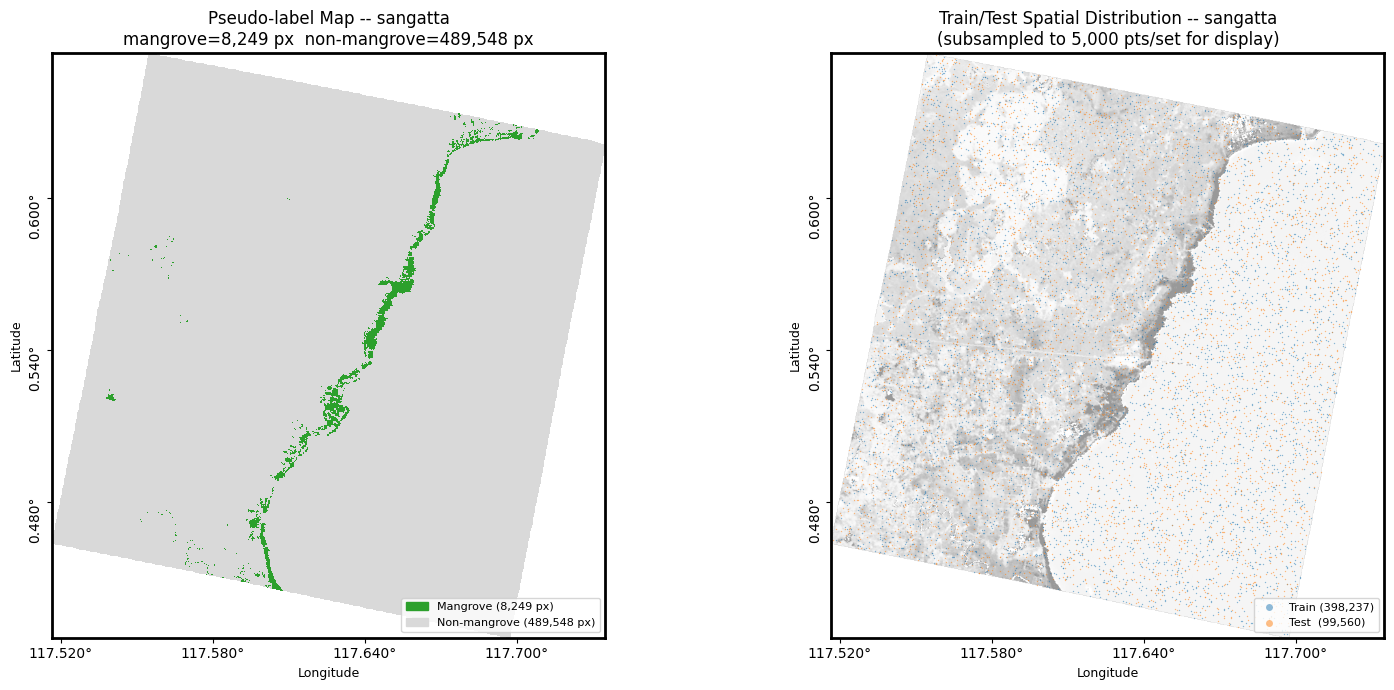

In [17]:
# ============================================================
# Pseudo-label map + train/test spatial distribution
# ============================================================
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from pyproj import Transformer as _ProjTransformer
from rasterio.transform import xy as _rtxy

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Helper: pixel (row, col) arrays -> (lon, lat) in EPSG:4326
_tr_to_4326 = _ProjTransformer.from_crs(data['crs'], 'EPSG:4326', always_xy=True)

def _pix_to_lonlat(r_arr, c_arr):
    xs, ys = _rtxy(data['transform'], r_arr, c_arr)
    return _tr_to_4326.transform(xs, ys)

# --- Panel 1: Pseudo-label raster map ---
label_vis = labels.astype(float)
label_vis[labels == -1] = np.nan

cmap_label = ListedColormap(['#d9d9d9', '#2ca02c'])
_img, _ext = reproject_array_to_4326(label_vis, data['crs'], data['transform'])
axes[0].imshow(_img, extent=_ext, origin='upper', cmap=cmap_label, vmin=0, vmax=1,
               interpolation='none')
axes[0].set_aspect('equal')
axes[0].set_title(f'Pseudo-label Map -- {SITE}\n'
                  f'mangrove={int((labels==1).sum()):,} px  '
                  f'non-mangrove={int((labels==0).sum()):,} px')
format_map_axes(axes[0], fontsize=9)
legend_0 = [
    Patch(color='#2ca02c', label=f'Mangrove ({int((labels==1).sum()):,} px)'),
    Patch(color='#d9d9d9', label=f'Non-mangrove ({int((labels==0).sum()):,} px)'),
]
axes[0].legend(handles=legend_0, loc='lower right', fontsize=8)

# --- Panel 2: Train/Test spatial distribution ---
valid_mask_2d = labels != -1
rows, cols    = np.where(valid_mask_2d)
n_valid       = len(rows)

# Reconstruct same split as training (identical random_state)
idx_all              = np.arange(n_valid)
idx_train, idx_test  = train_test_split(
    idx_all, test_size=0.2, stratify=y, random_state=42
)

# Background: MVI reprojected to 4326
_mvi_bg = np.clip(indices['MVI'], 0, 5).astype('float32')
_mvi_img, _mvi_ext = reproject_array_to_4326(_mvi_bg, data['crs'], data['transform'])
axes[1].imshow(_mvi_img, extent=_mvi_ext, origin='upper', cmap='Greys', alpha=0.4)

# Subsample for display (scatter too slow at 200k+ pts)
MAX_PTS = 5000
rng     = np.random.RandomState(0)

for idx_set, color, label_txt in [
    (idx_train, '#1f77b4', f'Train ({len(idx_train):,})'),
    (idx_test,  '#ff7f0e', f'Test  ({len(idx_test):,})'),
]:
    sub = idx_set if len(idx_set) <= MAX_PTS else \
          rng.choice(idx_set, MAX_PTS, replace=False)
    lons, lats = _pix_to_lonlat(rows[sub], cols[sub])
    axes[1].scatter(lons, lats,
                    c=color, s=1, alpha=0.5, linewidths=0, label=label_txt)

axes[1].set_aspect('equal')
axes[1].set_title(f'Train/Test Spatial Distribution -- {SITE}\n'
                  f'(subsampled to {MAX_PTS:,} pts/set for display)')
format_map_axes(axes[1], fontsize=9)
axes[1].legend(loc='lower right', fontsize=8, markerscale=5)

plt.tight_layout()
plt.savefig(OUT_FIGURES / f'pseudo_label_map_{SITE}_{SCENE_ID}.png',
            dpi=150, bbox_inches='tight')
plt.show()


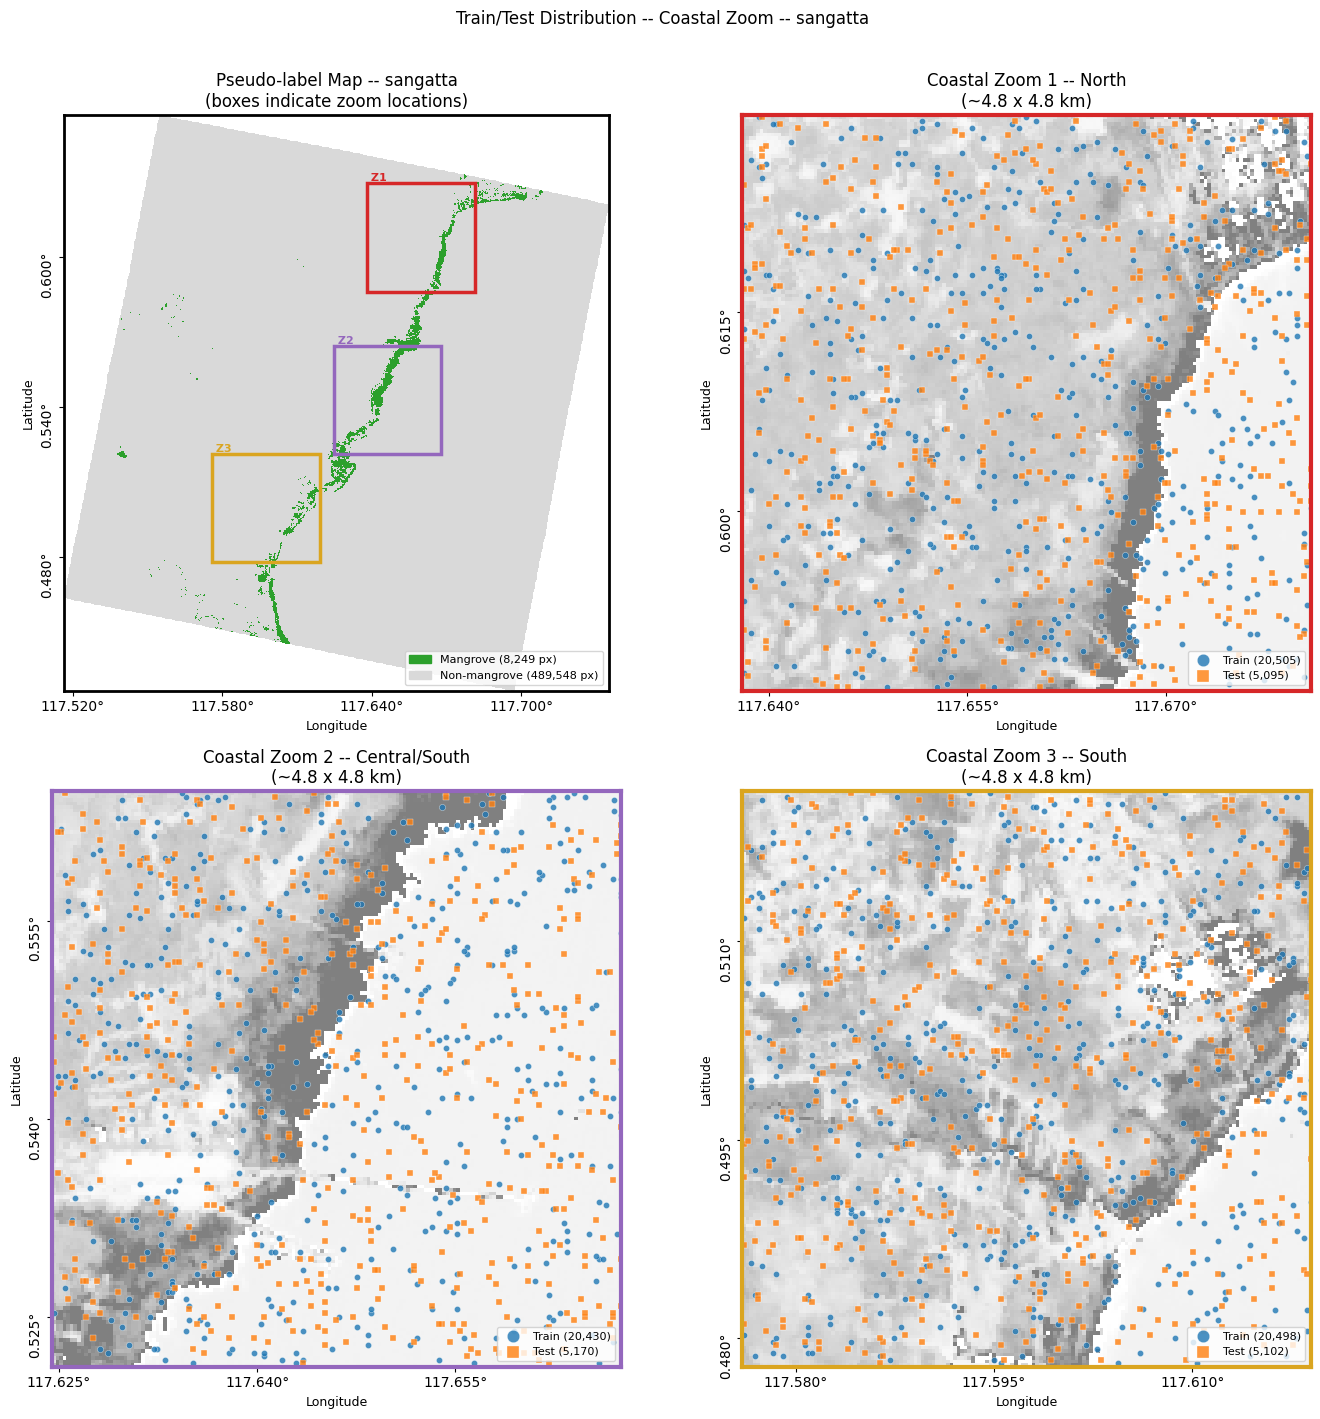

In [18]:
# ============================================================
# 2x2 coastal zoom panel
#   [0,0] full pseudo-label map with zoom location boxes
#   [0,1] zoom 1 -- red frame
#   [1,0] zoom 2 -- purple frame
#   [1,1] zoom 3 -- gold frame
# ============================================================
from matplotlib.patches import Patch, Rectangle
from matplotlib.colors import ListedColormap
from affine import Affine as _Affine
from pyproj import Transformer as _ProjTransformer
from rasterio.transform import xy as _rtxy

_tr_to_4326 = _ProjTransformer.from_crs(data['crs'], 'EPSG:4326', always_xy=True)

def _pix_to_lonlat(r_arr, c_arr):
    xs, ys = _rtxy(data['transform'], np.asarray(r_arr), np.asarray(c_arr))
    return _tr_to_4326.transform(xs, ys)

H_scene, W_scene = indices['MVI'].shape
ZOOM = 80  # half-window in pixels (~2.4 km at 30 m)

ZOOM_CENTERS = [
    (180, 530),   # northern coastal strip
    (420, 480),   # central/southern coastal area
    (580, 300),   # southern area
]
ZOOM_TITLES = [
    'Coastal Zoom 1 -- North',
    'Coastal Zoom 2 -- Central/South',
    'Coastal Zoom 3 -- South',
]
ZOOM_COLORS = ['#d62728', '#9467bd', '#DAA520']  # red, purple, gold

cmap_label = ListedColormap(['#d9d9d9', '#2ca02c'])

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
ax_main  = axes[0, 0]
ax_zooms = [axes[0, 1], axes[1, 0], axes[1, 1]]

# --- Main map: full pseudo-label extent ---
_img_main, _ext_main = reproject_array_to_4326(label_vis, data['crs'], data['transform'])
ax_main.imshow(_img_main, extent=_ext_main, origin='upper',
               cmap=cmap_label, vmin=0, vmax=1, interpolation='none')
ax_main.set_aspect('equal')
ax_main.set_title(f'Pseudo-label Map -- {SITE}\n(boxes indicate zoom locations)')
format_map_axes(ax_main, fontsize=9)
ax_main.legend(handles=[
    Patch(color='#2ca02c', label=f'Mangrove ({int((labels==1).sum()):,} px)'),
    Patch(color='#d9d9d9', label=f'Non-mangrove ({int((labels==0).sum()):,} px)'),
], loc='lower right', fontsize=8)

# --- Per-zoom: draw box on main map + render zoom panel ---
for i, ((cr, cc), ax_z, color, title) in enumerate(
        zip(ZOOM_CENTERS, ax_zooms, ZOOM_COLORS, ZOOM_TITLES), start=1):

    r0 = max(cr - ZOOM, 0);  r1 = min(cr + ZOOM, H_scene)
    c0 = max(cc - ZOOM, 0);  c1 = min(cc + ZOOM, W_scene)

    # Convert zoom window corners to EPSG:4326 for the main-map box
    corners_r = np.array([r0, r0, r1, r1, r0])
    corners_c = np.array([c0, c1, c1, c0, c0])
    lons_box, lats_box = _pix_to_lonlat(corners_r, corners_c)
    lon_min, lon_max = float(lons_box.min()), float(lons_box.max())
    lat_min, lat_max = float(lats_box.min()), float(lats_box.max())

    rect = Rectangle(
        (lon_min, lat_min), lon_max - lon_min, lat_max - lat_min,
        linewidth=2.5, edgecolor=color, facecolor='none', zorder=5,
    )
    ax_main.add_patch(rect)
    ax_main.text(lon_min, lat_max, f' Z{i}',
                 color=color, fontsize=8, fontweight='bold',
                 va='bottom', ha='left', zorder=6)

    # Windowed affine transform for this pixel slice
    win_transform = data['transform'] * _Affine.translation(c0, r0)

    # Background: MVI slice reprojected to 4326
    _mvi_slice = np.clip(indices['MVI'][r0:r1, c0:c1], 0, 5).astype('float32')
    _mvi_img, _mvi_ext = reproject_array_to_4326(_mvi_slice, data['crs'], win_transform)
    ax_z.imshow(_mvi_img, extent=_mvi_ext, origin='upper', cmap='Greys', alpha=0.5)

    MAX_ZOOM = 500
    rng_zoom = np.random.RandomState(42)

    for idx_set, pt_color, label_txt, marker in [
        (idx_train, '#1f77b4', 'Train', 'o'),
        (idx_test,  '#ff7f0e', 'Test',  's'),
    ]:
        in_window = (
            (rows[idx_set] >= r0) & (rows[idx_set] < r1) &
            (cols[idx_set] >= c0) & (cols[idx_set] < c1)
        )
        idx_win = np.where(in_window)[0]
        if len(idx_win) > MAX_ZOOM:
            idx_win = rng_zoom.choice(idx_win, MAX_ZOOM, replace=False)
        r_win = rows[idx_set[idx_win]]
        c_win = cols[idx_set[idx_win]]
        lons_w, lats_w = _pix_to_lonlat(r_win, c_win)
        ax_z.scatter(lons_w, lats_w, c=pt_color, s=20, alpha=0.8,
                     linewidths=0.3, edgecolors='white',
                     label=f'{label_txt} ({in_window.sum():,})',
                     marker=marker)

    y0_z, y1_z = _mvi_ext[2], _mvi_ext[3]
    ax_z.set_aspect(1 / np.cos(np.radians((y0_z + y1_z) / 2)))
    ax_z.set_title(f'{title}\n(~{(r1-r0)*30/1000:.1f} x {(c1-c0)*30/1000:.1f} km)')
    format_map_axes(ax_z, fontsize=9, spine_color=color, spine_width=3)
    ax_z.legend(loc='lower right', fontsize=8, markerscale=2)

plt.suptitle(f'Train/Test Distribution -- Coastal Zoom -- {SITE}', y=1.01)
plt.tight_layout()
plt.savefig(OUT_FIGURES / f'pseudo_label_zoom_{SITE}_{SCENE_ID}.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 4. Model Training

In [19]:
# ============================================================
# XGBoost baseline (untuned) â€” diagnostic comparison only
# Competition submission uses xgb_tuned (Section 4a)
# ============================================================
print('Training XGBoost...')
xgb_model = train_xgboost(X_train, y_train)
save_model(xgb_model, str(OUT_MODELS / f'xgb_{SITE}_{SCENE_ID}.joblib'))

Training XGBoost...
  XGB scale_pos_weight: 59.35  (neg=391,638 / pos=6,599)
  Model saved    : /content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping/outputs/models/xgb_sangatta_20250302_030003_92_4001.joblib


### 4a. Hyperparameter Tuning (RandomizedSearchCV, CV=5)

Tune XGBoost hyperparameters on the pseudo-label training set. Scoring: F1 (mangrove class). Final evaluation against GMW v3 in Section 8.


In [20]:
# ============================================================
# Hyperparameter tuning â€” XGBoost (primary)
# RandomizedSearchCV, n_iter=50, cv=5, scoring=F1 mangrove
# Best params JSON saved for reproducibility / inspection only
# ============================================================
import json as _json
import time

RUN_XGB = True

if RUN_XGB:
    print()
    print("=" * 50)
    print("  Tuning: XGBoost")
    print("=" * 50)
    t0 = time.time()
    xgb_tuned, xgb_best_params, xgb_best_cv_f1, xgb_search = tune_xgboost(
        X_train, y_train, n_iter=50, cv=5
    )
    xgb_elapsed = time.time() - t0
    print(f'  Tuning duration : {xgb_elapsed/60:.1f} min ({xgb_elapsed:.0f} s)')
    xgb_params_path = OUT_RESULTS / f'xgb_best_params_{SITE}_{SCENE_ID}.json'
    with open(xgb_params_path, 'w') as f:
        _json.dump({k: str(v) for k, v in xgb_best_params.items()}, f, indent=2)
    print(f'  Params saved    : {xgb_params_path.name}')
    save_model(xgb_tuned, str(OUT_MODELS / f'xgb_tuned_{SITE}_{SCENE_ID}.joblib'))
else:
    xgb_tuned = load_model(str(OUT_MODELS / f'xgb_tuned_{SITE}_{SCENE_ID}.joblib'))
    print("  XGB tuned loaded from disk (RUN_XGB=False)")


  Tuning: XGBoost
  [XGB] RandomizedSearchCV : 50 iter x 5-fold CV
  Scoring                  : F1 (mangrove class)
  scale_pos_weight         : 59.35  (neg=391,638 / pos=6,599)
  Training set             : 398,237 samples x 9 features
Fitting 5 folds for each of 50 candidates, totalling 250 fits

  Best CV F1 : 0.9620
  Best params:
    colsample_bytree      : 0.6987504251354405
    gamma                 : 0.3481521364198942
    learning_rate         : 0.21655847107808818
    max_depth             : 7
    min_child_weight      : 1
    n_estimators          : 539
    reg_alpha             : 0.036886947354532795
    reg_lambda            : 1.4143465009698453
    subsample             : 0.8010716092915446
  Tuning duration : 37.6 min (2255 s)
  Params saved    : xgb_best_params_sangatta_20250302_030003_92_4001.json
  Model saved    : /content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping/outputs/models/xgb_tuned_sangatta_20250302_030003_92_4001.joblib


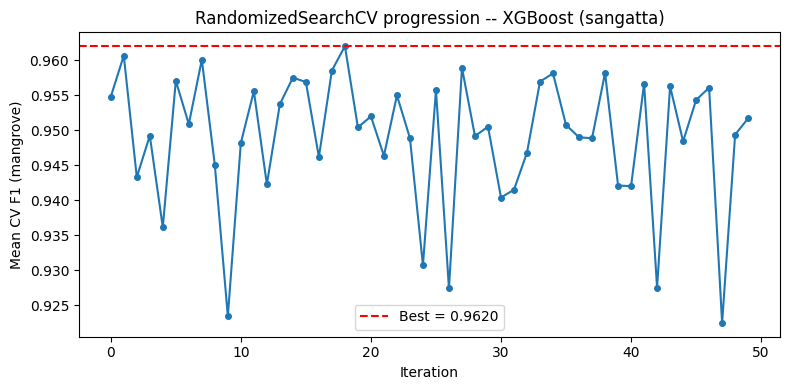

In [21]:
# ============================================================
# CV score progression -- XGBoost
# ============================================================
if RUN_XGB:
    scores = xgb_search.cv_results_['mean_test_score']
    plt.figure(figsize=(8, 4))
    plt.plot(scores, marker='o', markersize=4)
    plt.axhline(xgb_best_cv_f1, color='red', linestyle='--', label=f'Best = {xgb_best_cv_f1:.4f}')
    plt.xlabel('Iteration'); plt.ylabel('Mean CV F1 (mangrove)')
    plt.title(f'RandomizedSearchCV progression -- XGBoost ({SITE})')
    plt.legend(); plt.tight_layout()
    plt.savefig(OUT_FIGURES / f'xgb_search_progression_{SITE}_{SCENE_ID}.png', dpi=150)
    plt.show()

## 5. Evaluation

In [22]:
# Fit-check only: test set is drawn from pseudo-labels, not independent ground truth
xgb_metrics = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')


  XGBoost (pseudo-label test split):
              precision    recall  f1-score   support

Non-mangrove       1.00      1.00      1.00     97910
    Mangrove       0.90      1.00      0.95      1650

    accuracy                           1.00     99560
   macro avg       0.95      1.00      0.97     99560
weighted avg       1.00      1.00      1.00     99560



## 6. Wall-to-Wall Extent Map

In [23]:
# ============================================================
# Predict full scene using XGBoost (primary model)
# Apply same spatial constraint as training (candidate zone only)
# ============================================================
h, w        = list(indices.values())[0].shape
extent_map  = predict_extent(xgb_model, indices,
                              original_shape=(h, w),
                              candidate_mask=candidate_mask,
                              extra_features=extra_features)

# Save as GeoTIFF
extent_path = DATA_PROC / f'extent_mangrove_{SITE}_{SCENE_ID}.tif'
with rasterio.open(
    extent_path, 'w',
    driver='GTiff', height=h, width=w,
    count=1, dtype='int8',
    crs=data['crs'], transform=data['transform'],
    compress='lzw'
) as dst:
    dst.write(extent_map, 1)

print(f'Extent map saved : {extent_path}')

  Spatial constraint applied (outside candidate zone -> 0)
  Mangrove extent: 8,347 px


Extent map saved : /content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping/data/processed/extent_mangrove_sangatta_20250302_030003_92_4001.tif


## 7. Visualization

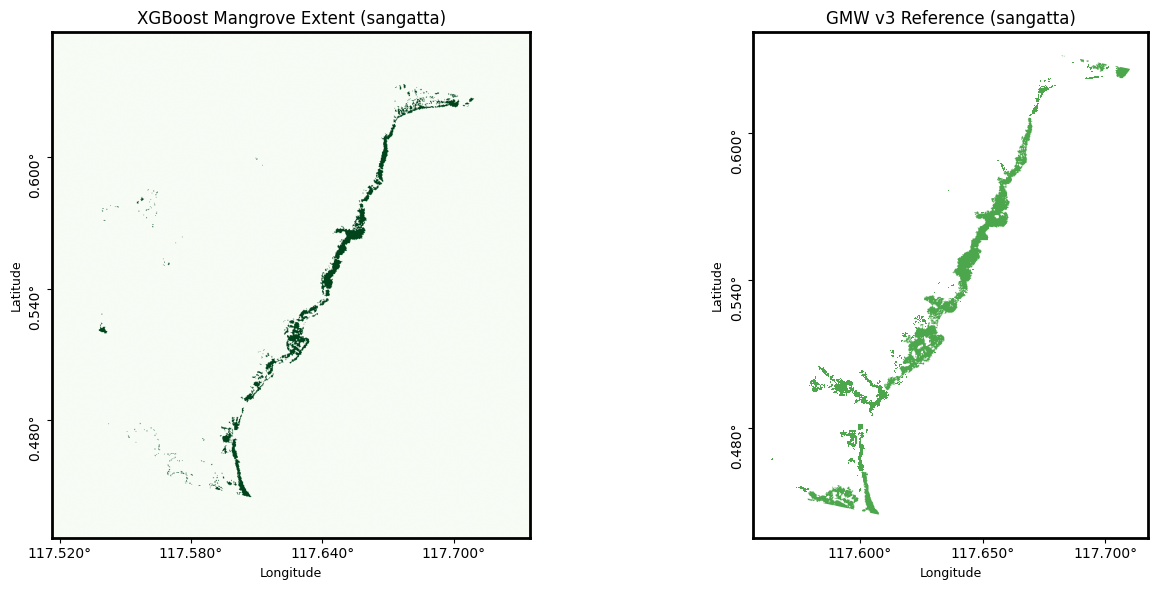

In [24]:
# ============================================================
# Extent map + GMW v3 overlay
# Adjust path if GMW v3 is stored elsewhere
# ============================================================
gmw_path = DATA_GMW / f'gmw_{SITE}_{SCENE_ID}.geojson'
gmw = gpd.read_file(gmw_path) if gmw_path.exists() else None

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XGBoost extent
_img, _ext = reproject_array_to_4326((extent_map == 1).astype('float32'),
                                      data['crs'], data['transform'])
axes[0].imshow(_img, extent=_ext, origin='upper', cmap='Greens')
axes[0].set_aspect('equal')
axes[0].set_title(f'XGBoost Mangrove Extent ({SITE})')
format_map_axes(axes[0], fontsize=9)

# GMW v3 reference
if gmw is not None:
    gmw_4326 = gmw.to_crs('EPSG:4326')
    gmw_4326.plot(ax=axes[1], color='green', alpha=0.7)
    axes[1].set_aspect('equal')
    axes[1].set_title(f'GMW v3 Reference ({SITE})')
else:
    axes[1].text(0.5, 0.5, 'GMW v3 not found', ha='center', va='center')
    axes[1].set_aspect('equal')
    axes[1].set_title('GMW v3 (missing)')
format_map_axes(axes[1], fontsize=9)

plt.tight_layout()
plt.savefig(OUT_FIGURES / f'extent_map_{SITE}_{SCENE_ID}.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Evaluation vs GMW v3 (Independent Ground Truth)

Section 5 evaluated against the pseudo-label test split, which is circular
(MVI/NDMI are both feature and label source). This section compares the
predicted extent against GMW v3, an independent reference never used in
training. These are the real accuracy figures.

The commission-omission error maps visualize where the model over-predicts
(commission, red) and under-predicts (omission, orange) relative to GMW v3,
with correctly identified mangrove in green.

In [25]:
# ============================================================
# Rasterize GMW v3 polygons to match the extent_map grid
# ============================================================
gmw_path = DATA_GMW / f'gmw_{SITE}_{SCENE_ID}.geojson'

gmw_raster = rasterize_gmw(
    str(gmw_path),
    reference_shape=extent_map.shape,
    transform=data['transform'],
    crs=data['crs'],
)

  GMW v3 rasterized : 13,522 mangrove px (1.96%)


In [26]:
# ============================================================
# Evaluate XGBoost extent vs GMW v3
# eval_mask = candidate_mask -> fair comparison (only where model
# was allowed to predict mangrove)
# ============================================================
gmw_eval = evaluate_against_gmw(
    extent_map,
    gmw_raster,
    eval_mask=candidate_mask,
    model_name='XGBoost',
)

# Save metrics
gmw_eval['metrics_table'].to_csv(
    OUT_RESULTS / f'gmw_eval_{SITE}_{SCENE_ID}.csv', index=False
)


  Evaluation vs GMW v3 -- XGBoost
  domain        : candidate zone
  pixels        : 57,014
  -----------------------------------
  Overall Acc   : 0.8868
  Cohen kappa   : 0.5506
  Precision     : 0.6229  (of predicted mangrove, how many correct)
  Recall        : 0.6112  (of true mangrove, how many found)
  F1 (mangrove) : 0.6170
  IoU (mangrove): 0.4461
  -----------------------------------
  Confusion matrix [rows=true, cols=pred]:
                 pred_non   pred_mang
  true_non         45,360      3,148
  true_mang         3,307      5,199


  Spatial constraint applied (outside candidate zone -> 0)
  Mangrove extent: 8,237 px
XGB tuned prediction: 6.4 s

  Evaluation vs GMW v3 -- XGBoost Tuned
  domain        : candidate zone
  pixels        : 57,014
  -----------------------------------
  Overall Acc   : 0.8869
  Cohen kappa   : 0.5484
  Precision     : 0.6247  (of predicted mangrove, how many correct)
  Recall        : 0.6050  (of true mangrove, how many found)
  F1 (mangrove) : 0.6147
  IoU (mangrove): 0.4437
  -----------------------------------
  Confusion matrix [rows=true, cols=pred]:
                 pred_non   pred_mang
  true_non         45,417      3,091
  true_mang         3,360      5,146
Model comparison vs GMW v3:
        Model    Kappa  Precision   Recall       F1      IoU
XGBoost Tuned 0.548414   0.624742 0.604985 0.614705 0.443735
  Saved : /content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping/outputs/figures/confusion_xgb_tuned_sangatta_20250302_030003_92_4001.png


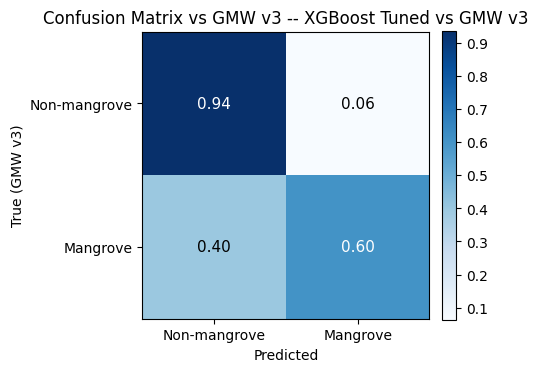

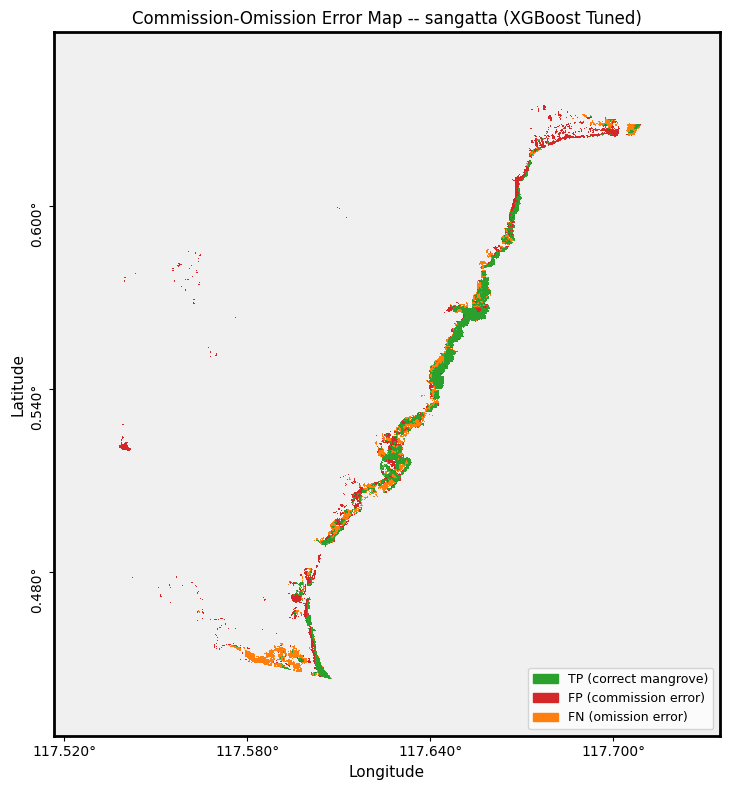

In [27]:
# ============================================================
# Evaluate XGBoost tuned vs GMW v3
# ============================================================
import time
import pandas as pd
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

h, w = list(indices.values())[0].shape

t0 = time.time()
extent_xgb_tuned = predict_extent(
    xgb_tuned, indices,
    original_shape=(h, w),
    candidate_mask=candidate_mask,
    extra_features=extra_features,
)
print(f'XGB tuned prediction: {time.time()-t0:.1f} s')
gmw_eval_xgb_tuned = evaluate_against_gmw(
    extent_xgb_tuned, gmw_raster,
    eval_mask=candidate_mask,
    model_name='XGBoost Tuned',
)

df_compare = pd.DataFrame([{
    'Model'    : 'XGBoost Tuned',
    'Kappa'    : gmw_eval_xgb_tuned['kappa'],
    'Precision': gmw_eval_xgb_tuned['precision'],
    'Recall'   : gmw_eval_xgb_tuned['recall'],
    'F1'       : gmw_eval_xgb_tuned['f1_mangrove'],
    'IoU'      : gmw_eval_xgb_tuned['IoU'],
}])
print('Model comparison vs GMW v3:')
print(df_compare.to_string(index=False))
df_compare.to_csv(
    OUT_RESULTS / f'model_comparison_{SITE}_{SCENE_ID}.csv', index=False
)

plot_confusion_matrix(
    gmw_eval_xgb_tuned['confusion_matrix'],
    model_name='XGBoost Tuned vs GMW v3',
    normalize=True,
    save_path=str(OUT_FIGURES / f'confusion_xgb_tuned_{SITE}_{SCENE_ID}.png'),
)

# ============================================================
# Commission-omission error map -- XGBoost Tuned
# Reprojected to EPSG:4326 with lat/lon axes
# green=TP  red=FP (commission)  orange=FN (omission)
# ============================================================
_cmap_agree = ListedColormap(['#f0f0f0', '#2ca02c', '#d62728', '#ff7f0e'])
_agree      = build_agree_array(extent_xgb_tuned, gmw_raster, eval_mask=candidate_mask)
_agree_img, _agree_ext = reproject_array_to_4326(
    _agree.astype(np.float32), data['crs'], data['transform']
)
_y0, _y1 = _agree_ext[2], _agree_ext[3]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(_agree_img, cmap=_cmap_agree, vmin=0, vmax=3,
          extent=_agree_ext, origin='upper', interpolation='none')
ax.set_aspect(1 / np.cos(np.radians((_y0 + _y1) / 2)))
ax.set_title(f'Commission-Omission Error Map -- {SITE} (XGBoost Tuned)')
format_map_axes(ax)
ax.legend(handles=[
    Patch(color='#2ca02c', label='TP (correct mangrove)'),
    Patch(color='#d62728', label='FP (commission error)'),
    Patch(color='#ff7f0e', label='FN (omission error)'),
], loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_FIGURES / f'commission_omission_xgb_tuned_{SITE}_{SCENE_ID}.png',
            dpi=150, bbox_inches='tight')
plt.show()


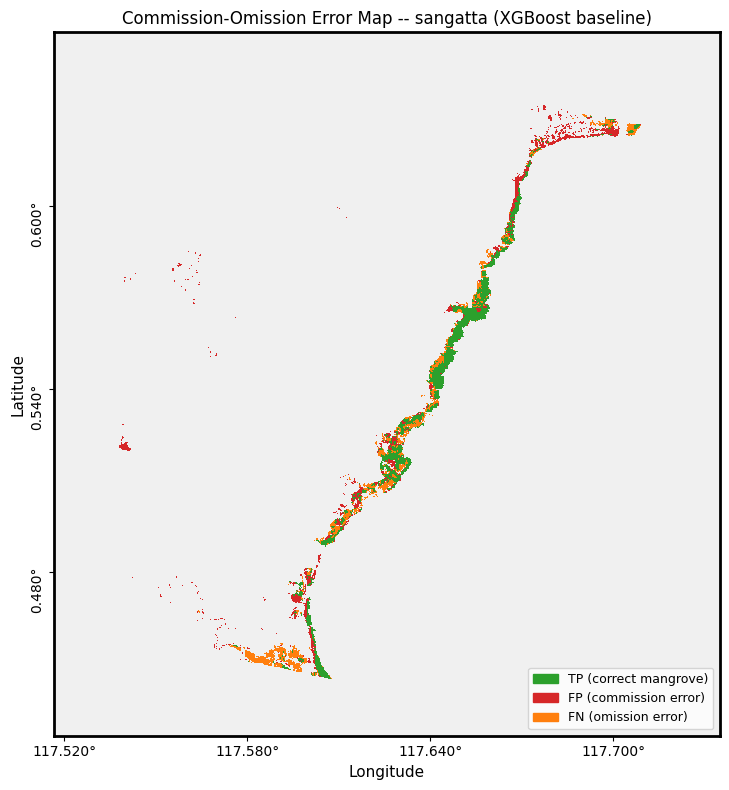

In [28]:
# ============================================================
# Commission-omission error map -- XGBoost baseline
# Reprojected to EPSG:4326 with lat/lon axes
# green=TP  red=FP (commission)  orange=FN (omission)
# ============================================================
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

_cmap_agree = ListedColormap(['#f0f0f0', '#2ca02c', '#d62728', '#ff7f0e'])
_agree      = build_agree_array(extent_map, gmw_raster, eval_mask=candidate_mask)
_agree_img, _agree_ext = reproject_array_to_4326(
    _agree.astype(np.float32), data['crs'], data['transform']
)
_y0, _y1 = _agree_ext[2], _agree_ext[3]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(_agree_img, cmap=_cmap_agree, vmin=0, vmax=3,
          extent=_agree_ext, origin='upper', interpolation='none')
ax.set_aspect(1 / np.cos(np.radians((_y0 + _y1) / 2)))
ax.set_title(f'Commission-Omission Error Map -- {SITE} (XGBoost baseline)')
format_map_axes(ax)
ax.legend(handles=[
    Patch(color='#2ca02c', label='TP (correct mangrove)'),
    Patch(color='#d62728', label='FP (commission error)'),
    Patch(color='#ff7f0e', label='FN (omission error)'),
], loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_FIGURES / f'commission_omission_{SITE}_{SCENE_ID}.png',
            dpi=150, bbox_inches='tight')
plt.show()
